# Ejercicio 2 — Árbol con load_diabetes

Vamos a predecir la progresión de la diabetes un año después del diagnóstico.

Dataset: from sklearn.datasets import load_diabetes — 442 pacientes, 10 features médicas ya estandarizadas.

Tarea:

Cargar el dataset:
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
X, y = data.data, data.target
Train/test split 80/20, random_state=42. Los datos ya están escalados — no necesitas estandarizar.
Entrenar un árbol con max_depth=3 y reportar R² de train Y test.
Repetir con max_depth=5, 10, sin límite. ¿En cuál hay más overfitting?
Visualizar el árbol con max_depth=3 (con plot_tree).
Interpretar: ¿cuál es la primera variable que el árbol usa para dividir? ¿Por qué tiene sentido (puedes ver el significado de las features en data.DESCR)?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

**Cargar dataset**

In [35]:
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

In [36]:
print("Primeras filas del DataFrame:")
display(X.head(10))

print("Ultimas filas del DataFrame:")
print(X.tail(5))

print("Informacion del DataFrame:")
print(X.info())

Primeras filas del DataFrame:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


Ultimas filas del DataFrame:
          age       sex       bmi  ...        s4        s5        s6
437  0.041708  0.050680  0.019662  ... -0.002592  0.031193  0.007207
438 -0.005515  0.050680 -0.015906  ...  0.034309 -0.018114  0.044485
439  0.041708  0.050680 -0.015906  ... -0.011080 -0.046883  0.015491
440 -0.045472 -0.044642  0.039062  ...  0.026560  0.044529 -0.025930
441 -0.045472 -0.044642 -0.073030  ... -0.039493 -0.004222  0.003064

[5 rows x 10 columns]
Informacion del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s

In [37]:
print("Estadisticas descriptivas del DataFrame:")
print(X.describe())

Estadisticas descriptivas del DataFrame:
                age           sex  ...            s5            s6
count  4.420000e+02  4.420000e+02  ...  4.420000e+02  4.420000e+02
mean  -2.511817e-19  1.230790e-17  ...  9.268604e-17  1.130318e-17
std    4.761905e-02  4.761905e-02  ...  4.761905e-02  4.761905e-02
min   -1.072256e-01 -4.464164e-02  ... -1.260971e-01 -1.377672e-01
25%   -3.729927e-02 -4.464164e-02  ... -3.324559e-02 -3.317903e-02
50%    5.383060e-03 -4.464164e-02  ... -1.947171e-03 -1.077698e-03
75%    3.807591e-02  5.068012e-02  ...  3.243232e-02  2.791705e-02
max    1.107267e-01  5.068012e-02  ...  1.335973e-01  1.356118e-01

[8 rows x 10 columns]


In [38]:
print("Tipos originales:")
print(X.dtypes)

Tipos originales:
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object


In [39]:
n_duplicados = X.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [40]:
print("Verificacion de datos nulos:")
print(X.isnull().sum())

Verificacion de datos nulos:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


**Dividir dataset**

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Entrenar Modelos**

In [43]:
depths = [3, 5, 10, None]
results = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    results.append({'max_depth': depth, 'R2_train' : r2_train, 'R2_test': r2_test})


**Resultados**

In [44]:
results_df = pd.DataFrame(results)
print('\nResultados:\n')
print(results_df)


Resultados:

   max_depth  R2_train   R2_test
0        3.0  0.516977  0.329445
1        5.0  0.668606  0.334482
2       10.0  0.938186  0.171790
3        NaN  1.000000  0.060654


**Visualizar arbol (max_depth=3)**

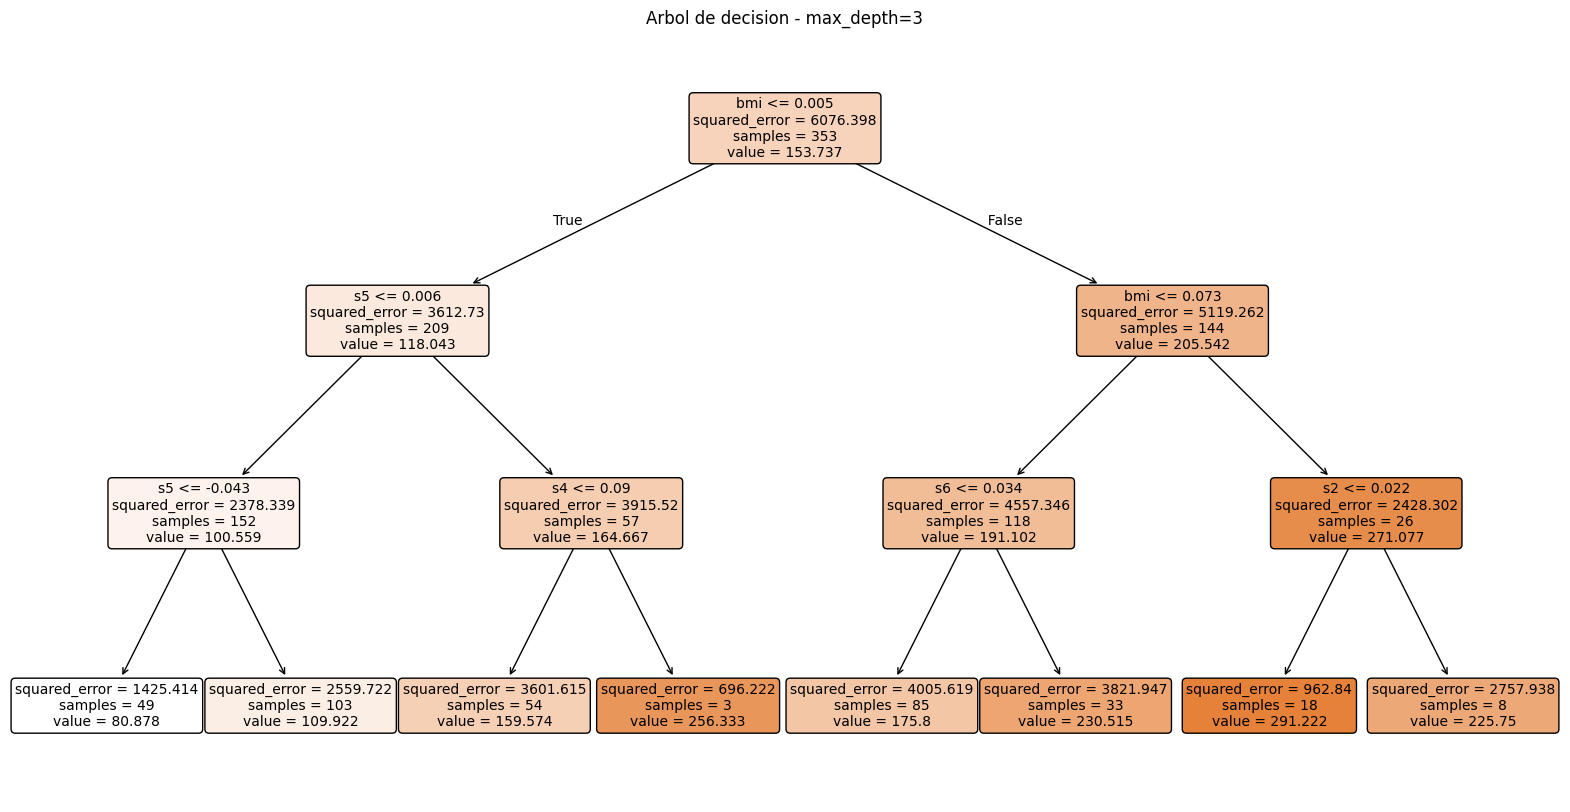

In [45]:
model_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)
model_depth3.fit(X_train, y_train)
plt.figure(figsize=(20,10))
plot_tree(model_depth3, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title('Arbol de decision - max_depth=3')
plt.show()

**Primera variable utilizada**

In [46]:
first_feature = X.columns[model_depth3.tree_.feature[0]]
print('\nPrimera variable utilizada por el arbol:')
print(first_feature)


Primera variable utilizada por el arbol:
bmi


**Descripcion features**

In [47]:
print('\nDescripcion del dataset:\n')
print(data.DESCR)


Descripcion del dataset:

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10

**Regresion Lineal**

In [49]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)


**KNN Regressor**

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = root_mean_squared_error(y_test, y_pred_knn)

**Comparacion de resultados**

In [51]:
results = pd.DataFrame({'Modelo': ['Regresion Lineal', 'KNN Regressor'], 'R2': [r2_linear, r2_knn], 'MAE': [mae_linear, mae_knn], 'RMSE': [rmse_linear, rmse_knn]})
print('\nResultados:\n')
print(results)


Resultados:

             Modelo        R2        MAE       RMSE
0  Regresion Lineal  0.452603  42.794095  53.853446
1     KNN Regressor  0.424809  42.777528  55.203713


**Visualizacion**

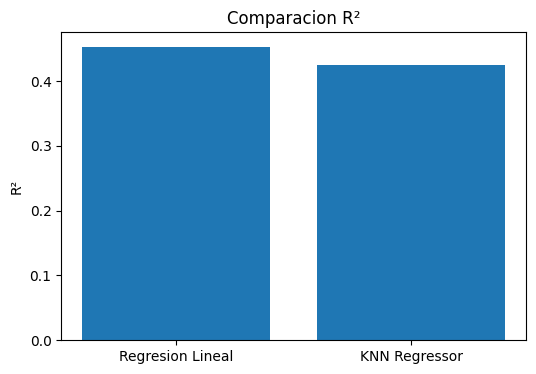

In [52]:
plt.figure(figsize=(6,4))
plt.bar(results['Modelo'], results['R2'])
plt.title('Comparacion R²')
plt.ylabel('R²')
plt.show()
